<a href="https://colab.research.google.com/github/tlmartiner/Integracion_de_datos_y_prospectiva/blob/main/Modelamiento_Del_Riesgo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Caso de Estudio**

Una FINTECH quiere estimar las pérdidas asociadas con el riesgo derivado de los fallos tecnológicos en transacciones de sus clientes a través de sus canales electrónicos.

Estos fallos pueden generar interrupciones, transacciones fallidas y pérdidas de valor, afectando la confianza de los usuarios y la estabilidad financiera de la organización.

El objetivo principal es caracterizar el riesgo operacional asociado a dichas fallas y construir un modelo cuantitativo que permita estimar:

- La distribución agregada de pérdidas (LDA).

- Los indicadores de riesgo: Media, Varianza, Asimetría, OpVar, NPE, NPNE, NPC.

- Los niveles de frecuencia y severidad mediante K-Medoids.

- Y finalmente, identificar las celdas más críticas dentro de la matriz de eventos, especialmente la Celda (4,3), que representa combinaciones de frecuencia y severidad relevantes.

**0. Se procede con la carga de las librerias de trabajo**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**1. Se crean los clusters para las variables de entrada**

In [2]:
def KMedoids(X):

  #Se configura el modelo K-Medoids
  XC=np.zeros((5,1))
  XC[:,0]=np.sort(np.random.uniform(low=np.min(X), high=np.max(X), size=5))

  for k in range(len(X)):
      nff=np.argmin(np.abs(XC[:,0]-X[k]))
      XC[nff,0]=(XC[nff,0]+X[k])/2

  XC=np.sort(XC)

  #Se procede con la configuración de la base de xcada cluster
  sigma=np.zeros((5,1))

  for k in range(5):
      sigma[k,0]=np.sum(np.abs(XC[:,]-XC[k,]))/4


  return XC,sigma

**2. Se procede con la carga de los datos.**

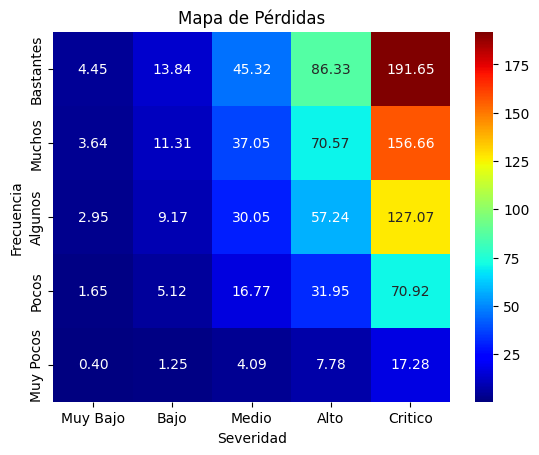

Los cluster para la frecuencia son:
['Muy Pocos', 'Pocos', 'Algunos', 'Muchos', 'Bastantes']
[[ 1.07267262  4.40324251  7.88916867  9.72687543 11.89905183]]
Los cluster para la severidad son:
['Muy Bajo', 'Bajo', 'Medio', 'Alto', 'Critico']
[[ 0.37394726  1.16281852  3.80911117  7.25507449 16.10639724]]


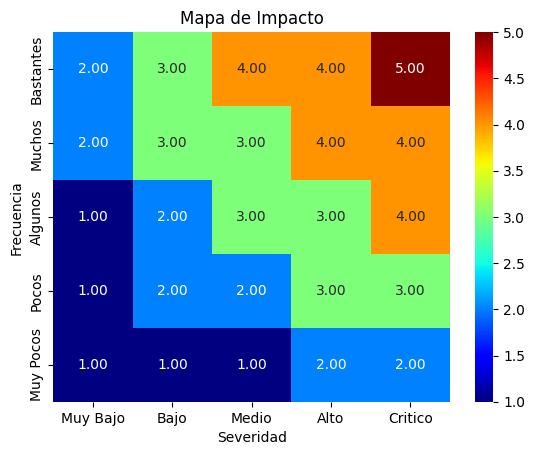

,Frecuencia,ClusterFrecuencia,Severidad,ClusterSeveridad,Impacto
0,1.0,0.0,0.5374,0.0,0.5374
1,4.0,1.0,1.1978,1.0,4.7912
2,5.0,1.0,0.4269,0.0,2.1345
3,6.0,1.0,1.0814,1.0,6.4884
4,7.0,2.0,1.2105,1.0,8.4735
...,...,...,...,...,...
696,1.0,0.0,0.5747,0.0,0.5747
697,6.0,1.0,0.7209,0.0,4.3254
698,10.0,3.0,0.3628,0.0,3.6280
699,4.0,1.0,0.2715,0.0,1.0860


,Fechas,Transacciones Diarias,Valor Transado (millones),Transacciones Fallidas,Valor Generado Promedio (Millones),Descripción Evento
202,2009-07-22,125,16.8511,7,11.2667,"Caída total del sistema por más de 24 horas, p..."
228,2009-08-17,80,40.0149,7,7.2316,Degradación severa del rendimiento por más de ...
298,2009-10-26,105,22.9937,8,10.4570,"Caída total del sistema por más de 24 horas, p..."
329,2009-11-26,100,13.7461,7,10.6269,"Caída total del sistema por más de 24 horas, p..."
405,2011-02-25,110,45.0293,7,7.3845,Degradación severa del rendimiento por más de ...
410,2011-03-02,95,24.4764,8,9.8843,"Caída total del sistema por más de 24 horas, p..."
627,2011-10-05,95,27.2916,8,5.9229,Degradación severa del rendimiento por más de ...
631,2011-10-09,125,24.1370,8,6.0314,Degradación severa del rendimiento por más de ...


In [3]:
nxl='/content/drive/MyDrive/SEMESTRE 9/Integración de datos y prospectiva/Bases de datos/5. FallasTecnológicas.xlsx'
XDB=pd.read_excel(nxl)
XDB.head()
#print(XDB.dtypes)

#Modelamos la variable de Frecuencia - KMedoids
np.random.seed(42)
XCf=np.array(XDB.iloc[1:,3])
X=XCf
XCf,sigmaf=KMedoids(X)
lbf=['Muy Pocos','Pocos','Algunos','Muchos','Bastantes']

#Modelamos la variable de Severidad
XCs=np.array(XDB.iloc[1:,4])
X=XCs
XCs,sigmas=KMedoids(X)
lbs=['Muy Bajo','Bajo','Medio','Alto','Critico']

#Modelamos el mapa de pérdida
MP=np.outer(XCf,XCs)
MPo=MP[::-1,:]  #Quedaron ordenados
lbfo=lbf[::-1]  #Labels ordenados

plt.figure()
sns.heatmap(MPo,annot=True,cmap='jet',fmt='.2f')
plt.xlabel('Severidad')
plt.xticks(np.arange(len(lbs))+0.5,lbs)
plt.ylabel('Frecuencia')
plt.yticks(np.arange(len(lbfo))+0.5,lbfo)
plt.title('Mapa de Pérdidas')
plt.show()

print('Los cluster para la frecuencia son:')
print(lbf)
print(XCf.transpose())
print('Los cluster para la severidad son:')
print(lbs)
print(XCs.transpose())

#Matriz de impacto - Cuáles cuadritos tienen un mayor impacto para las finanzas de la organización
#Donde se tiene que tener un mayor énfasis en la gestión de riesgos
MI = np.zeros((5,5))
MI = np.array([[1,1,1,2,2],
       [1,2,2,3,3],
       [1,2,3,3,4],
       [2,3,3,4,4],
       [2,3,4,4,5]])
MIo=MI[::-1,:]

plt.figure()
sns.heatmap(MIo,annot=True,cmap='jet',fmt='.2f')
plt.xlabel('Severidad')
plt.xticks(np.arange(len(lbs))+0.5,lbs)
plt.ylabel('Frecuencia')
plt.yticks(np.arange(len(lbfo))+0.5,lbfo)
plt.title('Mapa de Impacto')
plt.show()

#Se clasifican los datos por cluster en frecuencia y en severidad
Xf=np.array(XDB.iloc[:,3])  #Frecuencia
Xs=np.array(XDB.iloc[:,4])  #Severidad
nCf=np.zeros((len(Xf),1))  #Que cluster es?
nCs=np.zeros((len(Xs),1))  #Que cluster es?
for k in range(len(Xf)):
  nCf[k]=np.argmin(np.abs(XCf-Xf[k]))
  nCs[k]=np.argmin(np.abs(XCs-Xs[k]))

tabla=np.column_stack((Xf,nCf,Xs,nCs,Xf*Xs))
df=pd.DataFrame(tabla)
df.columns = ["Frecuencia","ClusterFrecuencia","Severidad","ClusterSeveridad","Impacto"]
display(df)
df.to_excel('ClustersAnalysis.xlsx')


tabla23=tabla[(tabla[:,1]==2) & (tabla[:,3]==3)]
nf=np.where((tabla[:,1]==2) & (tabla[:,3]==3))
XDB.iloc[nf[0],:]

**2.1 Distribución agregada de las perdidas**

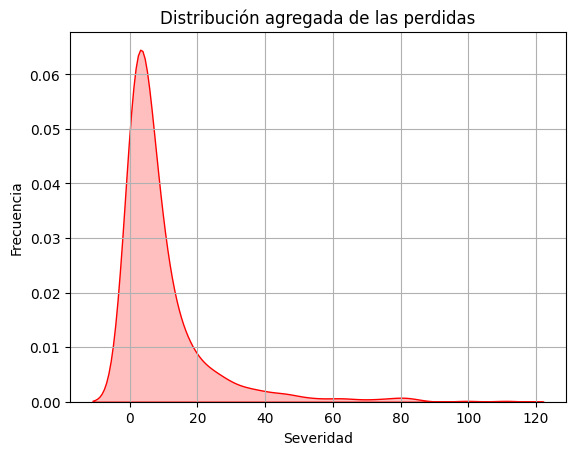

El costo de la poliza de aseguramiento de un puerto es:
102902.1000000008


,Media,Varianza,Asimetría,OpVar,NPE,NPNE,NPC
0,9.451113,13.707472,3.34836,102.9021,502.0,198.0,1.0


In [4]:
Xf=np.array(XDB.iloc[:,3])  #Frecuencia
Xs=np.array(XDB.iloc[:,4])  #Severidad
LDA=Xf*Xs

plt.figure()
sns.kdeplot(LDA,fill=True,color='red')
plt.xlabel('Severidad')
plt.ylabel('Frecuencia')
plt.title('Distribución agregada de las perdidas')
plt.grid()
plt.show()

#Se crea el vector para la presentación de resultados
pr=[]
#Parametros del Riesgo
pr.append(np.mean(LDA))
pr.append(np.std(LDA))
pr.append(skew(LDA))
#Pérdidas Esperadas - Cuantos pérdidas hay por debajo de la media
NPE=len(LDA[LDA<np.mean(LDA),])
#Cuantos hay por encima del OpVar
OpVar=np.percentile(LDA,99.9)
pr.append(OpVar)
print("El costo de la poliza de aseguramiento de un puerto es:")
print(OpVar*1000)
NPC=len(LDA[LDA>OpVar,])
#Cuantas son las pérdidas no esperadas
NPNE=len(LDA)-NPE-NPC
pr.append(NPE)
pr.append(NPNE)
pr.append(NPC)
pr=np.array(pr).reshape(1,7)
df=pd.DataFrame((pr))
df.columns = ["Media","Varianza","Asimetría","OpVar","NPE","NPNE","NPC"]
display(df)

**3. Se contabilizan el número de eventos de pérdida por celda o por cuadrito de la matriz. Aquí se clasifican los valores de frecuencia y de severidad.**

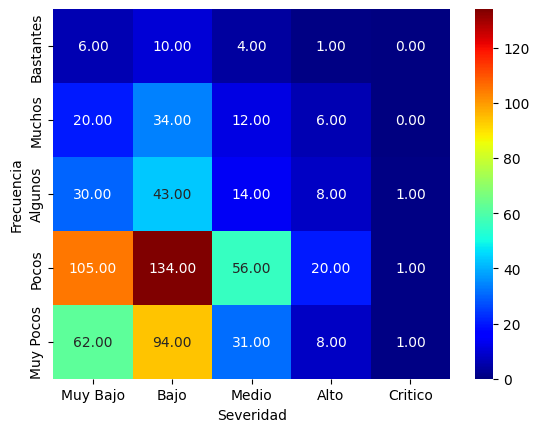

In [5]:
Mf=np.zeros((5,5,))

#Contenedores en tierra por cada cuadrito
XDf=np.array(XDB.iloc[:,3]); XDs=np.array(XDB.iloc[:,4])

for k in range(len(XDf)):
  nff=np.argmin(np.abs(XCf[:,0]-XDf[k]))
  nfs=np.argmin(np.abs(XCs[:,0]-XDs[k]))
  Mf[nff,nfs]+=1

#Eventos de pérdida por celda
Mfo=Mf[::-1,:]
lbf=lbf[::-1]

plt.figure()
sns.heatmap(Mfo,annot=True,cmap='jet',fmt='.2f')
plt.xlabel('Severidad')
plt.xticks(np.arange(len(lbs))+0.5,lbs)
plt.ylabel('Frecuencia')
plt.yticks(np.arange(len(lbf))+0.5,lbf)
plt.show()

La grafica es el mapeo bidimensional de las pérdidas. Producto entre la severidad y la frecuencia. Agrupación de los datos por cluster.

**4. Se quiere calcular la pérdida cuando se tienen 5 fallas tecnologicas y cada uno de ellas cuesta un total de 10 KUSD/Falla (Matriz de Pertenencia del Riesgo)**

Los labels de los cluster son:

['Bastantes', 'Muchos', 'Algunos', 'Pocos', 'Muy Pocos']
Los valores de pertenencia a cada uno de los clsuters:
[[0.86886363 0.99263829 0.7741191  0.57554304 0.53039074]]
El dato pertenece al cluster: 1
Los labels de los cluster son:

['Muy Bajo', 'Bajo', 'Medio', 'Alto', 'Critico']
Los valores de pertenencia a cada uno de los clsuters:
[[0.35729359 0.35228602 0.52533283 0.90992947 0.89487822]]
El dato pertenece al cluster: 3


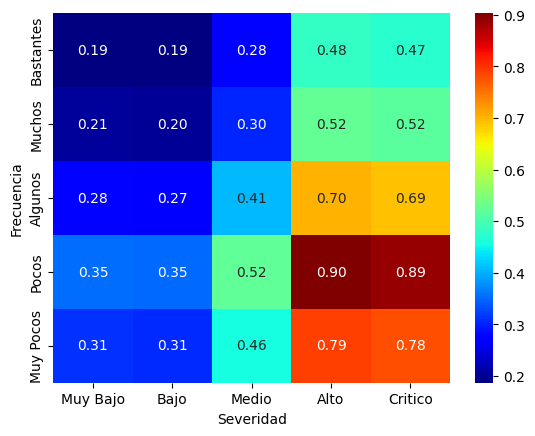

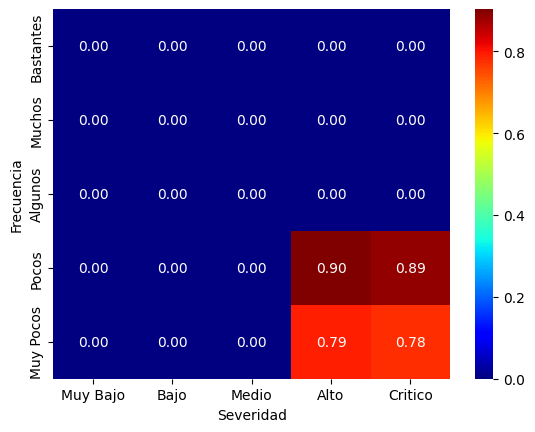

Integrar en la fila: 3
Integrar en la Columna: 3
El producto entre:

5 Fallas Tecnológicas y 10 KUSD/Falla es:
33.16960256273525


In [6]:
#Valor de frecuencia
Xff=5

VPf= np.exp(-0.5*((XCf[:,]-Xff)/sigmaf)**2)

print("Los labels de los cluster son:\n")
print(lbf)
print("Los valores de pertenencia a cada uno de los clsuters:")
print(np.transpose(VPf))
print("El dato pertenece al cluster:",np.argmax(VPf))

#Valor de Severidad
Xss=10

VPs=np.exp(-0.5*((XCs[:,]-Xss)/sigmas)**2)
print("Los labels de los cluster son:\n")
print(lbs)
print("Los valores de pertenencia a cada uno de los clsuters:")
print(np.transpose(VPs))
print("El dato pertenece al cluster:",np.argmax(VPs))

#La matriz de pertenencia del riesgo es:
MPr=np.zeros((5,5))
MPr=np.outer(VPf,VPs)
MPro=MPr[::-1,:]

plt.figure()
sns.heatmap(MPro,annot=True,cmap='jet',fmt='.2f')
plt.xlabel('Severidad')
plt.xticks(np.arange(len(lbs))+0.5,lbs)
plt.ylabel('Frecuencia')
plt.yticks(np.arange(len(lbf))+0.5,lbf)
plt.show()

#Identificamos los cuadritos de integración de un dato
#digamos lo cuatro cuadritos con la mayor pertenencia
n=4
indices_top=np.argsort(MPro,axis=None)[-n:]
mask=np.zeros_like(MPro,dtype=int)
fil,col=np.unravel_index(indices_top,MPro.shape)
mask[fil,col]=1
MPro=MPro*mask

plt.figure()
sns.heatmap(MPro,annot=True,cmap='jet',fmt='.2f')
plt.xlabel('Severidad')
plt.xticks(np.arange(len(lbs))+0.5,lbs)
plt.ylabel('Frecuencia')
plt.yticks(np.arange(len(lbf))+0.5,lbf)
plt.show()

#Este dato se debe integrar a la matriz de Eventos
print("Integrar en la fila:",fil[-1])
print("Integrar en la Columna:",col[-1])

#Es un promedio ponderado
print("El producto entre:\n")
print("5 Fallas Tecnológicas y 10 KUSD/Falla es:")
LDAk=np.sum(MPo*MPro)/np.sum(MPro)
print(LDAk)

## **CONCLUSIÓN DEL ANÁLISIS**

- Media (LDA): 9.451113
- Desv. Est. (LDA): 13.707472
- Asimetría (skew): 3.348360 → distribución fuertemente sesgada a la derecha
- OpVar (p99.9): 102.902100

**Pérdidas:**

NPE (pérdidas por debajo de la media): 502

NPNE (pérdidas no esperadas): 198

NPC (pérdidas por encima de OpVar — catastróficas): 1

En los resultados obtenidos se puede ver que hubo 502 pérdidas esperadas (NPE), las cuales son las más comunes y de menor impacto, ya que están por debajo del valor promedio. Estas representan los fallos pequeños o recurrentes que ocurren con frecuencia en las operaciones tecnológicas. Por otro lado, se identificaron 198 pérdidas no esperadas (NPNE), que son menos frecuentes pero más importantes, porque superan la media y pueden generar afectaciones más grandes en el sistema. Finalmente, se encontró 1 pérdida catastrófica (NPC), la cual corresponde a un evento extremo con un impacto muy alto que sobrepasa el límite definido por el OpVar. Este resultado muestra cómo se distribuyen los diferentes niveles de pérdida y ayuda a entender qué tan expuesta está la FINTECH frente a los riesgos tecnológicos.

La empresa presenta un nivel de riesgo tecnológico moderado, lo que significa que, aunque la mayoría de las fallas son menores y se consideran parte del funcionamiento normal, aún existen aspectos que requieren atención. La gran cantidad de pérdidas esperadas muestra que hay fallos recurrentes que podrían mejorar con mantenimiento o actualización de los sistemas. Las pérdidas no esperadas revelan que, en ocasiones, ocurren eventos con un impacto mayor que podrían afectar la operación si no se controlan. Por último, el hecho de tener solo una pérdida catastrófica indica que los eventos extremos son raros, pero es importante contar con planes de contingencia y respaldo tecnológico para evitar consecuencias graves cuando lleguen a ocurrir.



En la ubicación (4,3) de mapa de evento de pérdida por celda, se puede ver que hay 8 eventos. Mirando la misma ubicación en el mapa de impacto, se visualiza que corresponde a un impacto 3 (Alto).

**Descripción impacto 3:** Degradación del rendimiento por varias horas, interrupción temporal de servicios clave, pérdida de datos parcial, incidentes de seguridad que afectan a un número considerable de clientes, errores en la interfaz de usuario que impiden realizar transacciones.

**Impacto en la Operación:** Disminución de la eficiencia operativa, afectación a cientos de miles de clientes.

**Impacto en el Cliente:** Insatisfacción del cliente, pérdida de productividad, riesgo de reputación.

**Impacto Financiero (USD):** Decenas de millones a cientos de millones

**Frecuencia:** Media

## **¿Cómo se puede gestionar este impacto?**

A través de un nivel de gestión moderado, con las siguientes activiades:

- Gestión de cambios rigurosa
- Pruebas de carga regulares
- Implementación de sistemas de detección de anomalías
- Análisis de riesgos continuo
- Capacitación del personal en gestión de riesgos

